# DNV-RP-F109 on-bottom stability screening with NeqSim

This example exercises NeqSim's typed, fail-closed screening kernel for submarine pipelines,
cables, and umbilicals. It compares vertical stability, transparent absolute-static lateral
stability, and a displacement supplied by an external response model.

> **Engineering boundary:** this notebook is an option-screening example, not DNV certification
> or design approval. Verify every factor, environmental load, hydrodynamic coefficient,
> pipe-soil parameter, response-model validity range, and acceptance criterion against the
> licensed project edition and independent engineering review.

## Calculation basis

The illustrative asset has hydrodynamic outside diameter $D=0.508$ m in seawater of density
$1025\ \mathrm{kg/m^3}$. Direction is relative to the asset axis, so $0^\circ$ is axial and
$90^\circ$ is normal. The static route calculates

$$
F_D=\frac{1}{2}f_H\rho C_D D(u_{c,n}+u_{w,n})^2,\quad
F_I=f_H\rho C_M\frac{\pi D^2}{4}a_n,\quad
F_L=\frac{1}{2}f_V\rho C_L D(u_{c,n}+u_{w,n})^2.
$$

The checks are $\gamma_VF_L/W_s$ vertically and
$\gamma_H(F_D+F_I)/[\mu\max(W_s-\gamma_VF_L,0)+R_p]$ laterally. Coefficients,
reduction factors, soil resistance, safety factors, storm duration, and submerged weight are
illustrative project inputs, not values supplied or endorsed by DNV.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")


def find_project_root():
    candidates = []
    configured = os.environ.get("NEQSIM_PROJECT_ROOT")
    if configured:
        candidates.append(Path(configured).resolve())
    current = Path.cwd().resolve()
    candidates.extend([current] + list(current.parents))
    for candidate in candidates:
        pom = candidate / "pom.xml"
        setup = candidate / "devtools" / "neqsim_dev_setup.py"
        if pom.exists() and setup.exists():
            return candidate
    return None


classpath_override = os.environ.get("NEQSIM_DNV_CLASSPATH")
project_root = find_project_root()

if classpath_override:
    import jpype

    if not jpype.isJVMStarted():
        jpype.startJVM(classpath=[classpath_override])
    JClass = jpype.JClass
    execution_mode = "compiled-classpath override"
elif project_root is not None:
    sys.path.insert(0, str(project_root / "devtools"))
    from neqsim_dev_setup import neqsim_classes, neqsim_init

    ns = neqsim_init(project_root=project_root, recompile=True, verbose=False)
    ns = neqsim_classes(ns)
    JClass = ns.JClass
    execution_mode = "NeqSim devtools"
else:
    import jpype
    from neqsim import jneqsim

    JClass = jpype.JClass
    execution_mode = "installed NeqSim package"

print(f"Execution mode: {execution_mode}")

Execution mode: compiled-classpath override


In [2]:
Input = JClass(
    "neqsim.process.mechanicaldesign.subsea.DnvRpF109OnBottomStabilityInput"
)
LoadCase = JClass(
    "neqsim.process.mechanicaldesign.subsea."
    "DnvRpF109OnBottomStabilityInput$LoadCase"
)
AssetType = JClass(
    "neqsim.process.mechanicaldesign.subsea."
    "DnvRpF109OnBottomStabilityInput$AssetType"
)
LateralMethod = JClass(
    "neqsim.process.mechanicaldesign.subsea."
    "DnvRpF109OnBottomStabilityInput$LateralMethod"
)
StandardEdition = JClass(
    "neqsim.process.mechanicaldesign.designstandards.StandardEdition"
)
StandardType = JClass(
    "neqsim.process.mechanicaldesign.designstandards.StandardType"
)
Kernel = JClass(
    "neqsim.process.engineering.calculation."
    "DnvRpF109OnBottomStabilityKernel"
)
Context = JClass(
    "neqsim.process.engineering.calculation.EngineeringCalculationContext"
)

In [3]:
def make_case(
    case_id,
    submerged_weight=3200.0,
    current_velocity=0.6,
    wave_velocity=1.2,
    wave_acceleration=0.8,
    current_direction=90.0,
    wave_direction=90.0,
    friction=0.5,
    passive_resistance=100.0,
    lift_coefficient=0.8,
    method="ABSOLUTE_STATIC",
    predicted_displacement=np.nan,
    allowable_displacement_diameters=np.nan,
    response_valid=None,
    response_basis=None,
):
    builder = LoadCase.builder()
    builder.caseId(case_id)
    builder.submergedWeightNPerM(submerged_weight)
    builder.currentVelocityMPerS(current_velocity)
    builder.waveVelocityMPerS(wave_velocity)
    builder.waveAccelerationMPerS2(wave_acceleration)
    builder.currentDirectionRelativeToPipeDeg(current_direction)
    builder.waveDirectionRelativeToPipeDeg(wave_direction)
    builder.dragCoefficient(1.0)
    builder.liftCoefficient(lift_coefficient)
    builder.inertiaCoefficient(3.0)
    builder.horizontalLoadReductionFactor(0.8)
    builder.verticalLoadReductionFactor(0.7)
    builder.soilFrictionCoefficient(friction)
    builder.passiveSoilResistanceNPerM(passive_resistance)
    builder.horizontalSafetyFactor(1.1)
    builder.verticalSafetyFactor(1.1)
    builder.stormDurationHours(3.0)
    builder.oscillationCount(1000.0)
    builder.lateralMethod(LateralMethod.valueOf(method))
    if method != "ABSOLUTE_STATIC":
        builder.predictedLateralDisplacementM(predicted_displacement)
        builder.allowableDisplacementDiameters(allowable_displacement_diameters)
        builder.responseModelWithinValidatedRange(response_valid)
        builder.responseModelBasis(response_basis)
    return builder.build()


def calculate_cases(load_cases):
    builder = Input.builder()
    builder.edition(StandardEdition.defaultEdition(StandardType.DNV_RP_F109))
    builder.assetType(AssetType.PIPELINE)
    builder.equipmentType("Pipeline")
    builder.outsideDiameterM(0.508)
    builder.seawaterDensityKgM3(1025.0)
    builder.gravitationalAccelerationMPerS2(9.81)
    builder.engineeringBasis(
        "Illustrative environmental ENV-1; geotechnical GEO-2; "
        "hydrodynamic HYD-3"
    )
    for load_case in load_cases:
        builder.addLoadCase(load_case)
    context = (
        Context.builder()
        .designCaseId("illustrative 20-inch seabed section")
        .addStandardReference(
            "DNV-RP-F109 2021-05, amended 2025-09, licensed project copy"
        )
        .build()
    )
    return Kernel().calculate(builder.build(), context)


def checks_frame(result):
    rows = []
    for check in result.getValue().getChecks():
        rows.append(
            {
                "case_id": str(check.getCaseId()),
                "limit_state": str(check.getLimitState()),
                "verdict": str(check.getVerdict()),
                "demand": float(check.getDemand()),
                "resistance": float(check.getResistance()),
                "utilization": float(check.getUtilization()),
                "unit": str(check.getUnit()),
            }
        )
    return pd.DataFrame(rows)


def utilization(assessment, limit_state):
    for check in assessment.getChecks():
        if str(check.getLimitState()) == limit_state:
            return float(check.getUtilization())
    raise ValueError(f"Missing limit state {limit_state}")

In [4]:
baseline_cases = [
    make_case(
        "installation",
        submerged_weight=2500.0,
        current_velocity=0.3,
        wave_velocity=0.7,
        wave_acceleration=0.5,
    ),
    make_case("operating"),
    make_case(
        "extreme external response",
        current_velocity=0.8,
        wave_velocity=1.5,
        wave_acceleration=1.0,
        method="EXTERNAL_RESPONSE_0_5D",
        predicted_displacement=0.22,
        response_valid=True,
        response_basis="Qualified response model QRM-1, verification record V-17",
    ),
]
baseline_result = calculate_cases(baseline_cases)
assert str(baseline_result.getStatus()) == "CALCULATED_REVIEW_REQUIRED"
assert baseline_result.getReadiness().isReady()

baseline = checks_frame(baseline_result)
display(
    baseline.style.format(
        {
            "demand": "{:.3f}",
            "resistance": "{:.3f}",
            "utilization": "{:.3f}",
        }
    )
)

,case_id,limit_state,verdict,demand,resistance,utilization,unit
0,installation,VERTICAL_STABILITY,PASS,160.376,2500.000,0.064,N/m
1,installation,ABSOLUTE_LATERAL_STABILITY,PASS,503.338,1269.812,0.396,N/m
2,operating,VERTICAL_STABILITY,PASS,519.617,3200.000,0.162,N/m
3,operating,ABSOLUTE_LATERAL_STABILITY,PASS,1181.078,1440.192,0.820,N/m
4,extreme external response,VERTICAL_STABILITY,PASS,848.387,3200.000,0.265,N/m
5,extreme external response,LATERAL_DISPLACEMENT,PASS,0.220,0.254,0.866,m


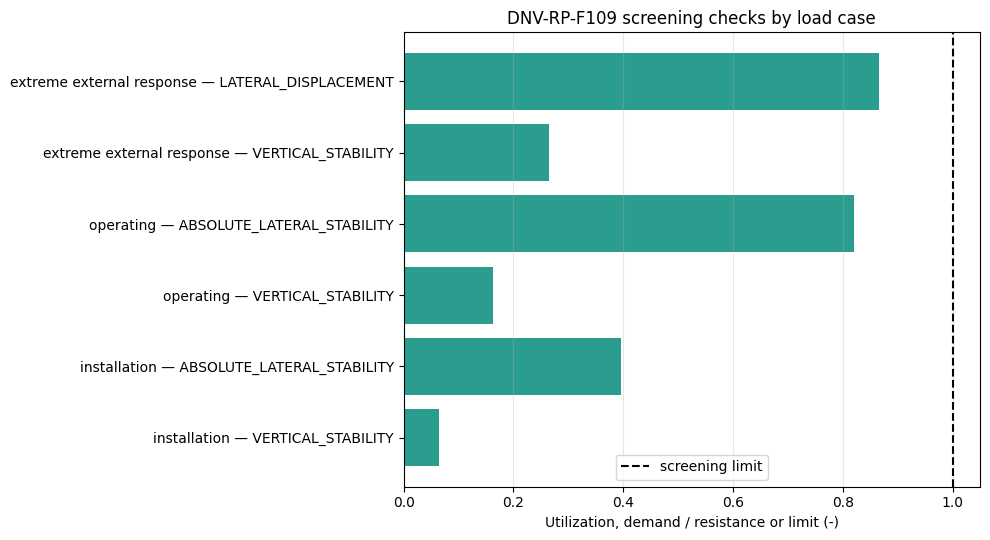

In [5]:
labels = baseline["case_id"] + " — " + baseline["limit_state"]
colors = np.where(baseline["utilization"] <= 1.0, "#2a9d8f", "#e76f51")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels, baseline["utilization"], color=colors)
ax.axvline(1.0, color="black", linestyle="--", label="screening limit")
ax.set_xlabel("Utilization, demand / resistance or limit (-)")
ax.set_title("DNV-RP-F109 screening checks by load case")
ax.grid(axis="x", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### Figure 1 discussion

**Observation:** all illustrative checks pass, but the external 0.5D displacement case governs at
about 0.87, followed by operating absolute-lateral utilization at about 0.82. Vertical
utilizations are much lower. **Mechanism:** the response route compares the supplied 0.22 m
movement with $0.5D=0.254$ m, while the static route combines drag and inertia against friction
and passive resistance after lift reduces normal weight. **Engineering implication:** a vertical
pass does not establish lateral stability, and a supplied response can govern even when static
cases pass. **Recommendation:** verify the external model range and project displacement
acceptability before using the result in a design decision.

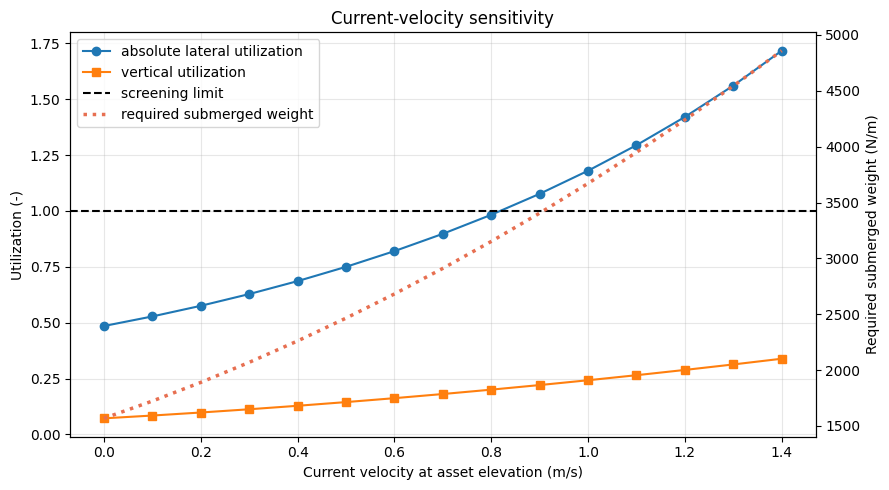

,current_m_per_s,lateral_utilization,vertical_utilization,required_weight_n_per_m
0,0.0,0.485118,0.072169,1568.308185
1,0.1,0.527945,0.084698,1722.956085
2,0.2,0.575448,0.098230,1889.975817
3,0.3,0.627978,0.112764,2069.367381
4,0.4,0.685938,0.128300,2261.130777
5,0.5,0.749794,0.144839,2465.266005
6,0.6,0.820084,0.162380,2681.773065
7,0.7,0.897432,0.180924,2910.651957
8,0.8,0.982564,0.200469,3151.902681
9,0.9,1.076326,0.221018,3405.525237


In [6]:
current_values = np.linspace(0.0, 1.4, 15)
lateral_values = []
vertical_values = []
required_weights = []

for current in current_values:
    result = calculate_cases(
        [make_case("operating sensitivity", current_velocity=float(current))]
    )
    assessment = result.getValue()
    lateral_values.append(
        utilization(assessment, "ABSOLUTE_LATERAL_STABILITY")
    )
    vertical_values.append(utilization(assessment, "VERTICAL_STABILITY"))
    required_weights.append(
        float(
            assessment.getCaseResults()
            .get(0)
            .getRequiredSubmergedWeightNPerM()
        )
    )

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(
    current_values,
    lateral_values,
    marker="o",
    label="absolute lateral utilization",
)
ax1.plot(
    current_values,
    vertical_values,
    marker="s",
    label="vertical utilization",
)
ax1.axhline(1.0, color="black", linestyle="--", label="screening limit")
ax1.set_xlabel("Current velocity at asset elevation (m/s)")
ax1.set_ylabel("Utilization (-)")
ax1.set_title("Current-velocity sensitivity")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    current_values,
    required_weights,
    color="#e76f51",
    linestyle=":",
    linewidth=2.5,
    label="required submerged weight",
)
ax2.set_ylabel("Required submerged weight (N/m)")

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc="upper left")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "current_m_per_s": current_values,
            "lateral_utilization": lateral_values,
            "vertical_utilization": vertical_values,
            "required_weight_n_per_m": required_weights,
        }
    )
)

### Figure 2 discussion

**Observation:** lateral utilization rises nonlinearly with current velocity and crosses the
screening limit within the sweep, while vertical utilization and required submerged weight also
increase. **Mechanism:** drag and lift scale with the square of combined normal velocity; inertia
is unchanged because the wave acceleration is fixed. Lift simultaneously raises the vertical
demand and reduces the effective normal weight available for friction. **Engineering implication:**
uncertainty in near-bed current and direction can change both load and resistance. **Recommendation:**
run the approved environmental joint-probability cases and coefficient envelopes, rather than
selecting one convenient velocity.

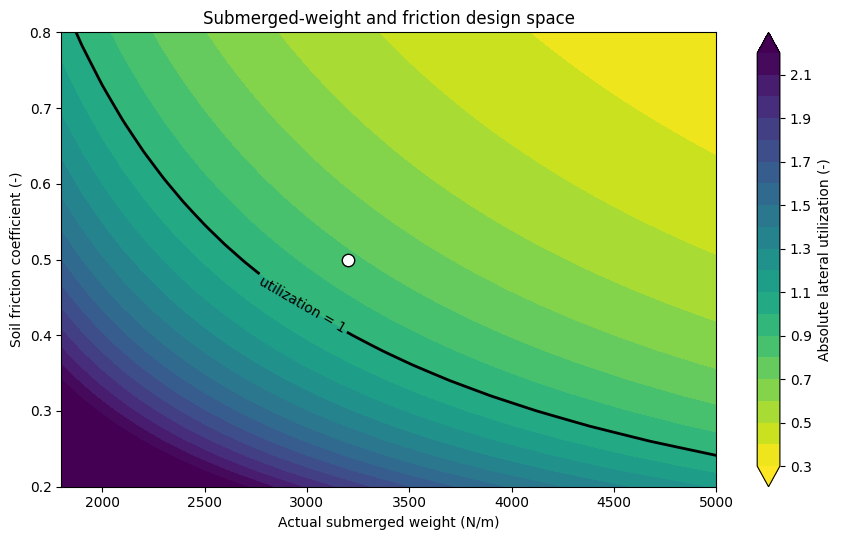

In [7]:
weights = np.linspace(1800.0, 5000.0, 33)
frictions = np.linspace(0.2, 0.8, 31)
weight_grid, friction_grid = np.meshgrid(weights, frictions)
utilization_grid = np.empty_like(weight_grid)

for row in range(friction_grid.shape[0]):
    for column in range(friction_grid.shape[1]):
        load_case = make_case(
            "design space",
            submerged_weight=float(weight_grid[row, column]),
            friction=float(friction_grid[row, column]),
        )
        assessment = calculate_cases([load_case]).getValue()
        utilization_grid[row, column] = utilization(
            assessment,
            "ABSOLUTE_LATERAL_STABILITY",
        )

fig, ax = plt.subplots(figsize=(9, 5.5))
levels = np.linspace(0.3, 2.2, 20)
filled = ax.contourf(
    weight_grid,
    friction_grid,
    utilization_grid,
    levels=levels,
    cmap="viridis_r",
    extend="both",
)
boundary = ax.contour(
    weight_grid,
    friction_grid,
    utilization_grid,
    levels=[1.0],
    colors="black",
    linewidths=2.0,
)
ax.clabel(boundary, fmt={1.0: "utilization = 1"})
ax.scatter([3200.0], [0.5], color="white", edgecolor="black", s=80)
ax.set_xlabel("Actual submerged weight (N/m)")
ax.set_ylabel("Soil friction coefficient (-)")
ax.set_title("Submerged-weight and friction design space")
fig.colorbar(filled, ax=ax, label="Absolute lateral utilization (-)")
plt.tight_layout()
plt.show()

### Figure 3 discussion

**Observation:** the baseline point at 3200 N/m and $\mu=0.5$ lies in the passing region at
about 0.82. At lower friction, considerably more submerged weight is required; the same load case
has a calculated static requirement of about 2682 N/m at $\mu=0.5$. **Mechanism:** friction
resistance scales with effective submerged weight after lift, while the 100 N/m passive resistance
remains fixed. **Engineering implication:** coating weight and an assumed friction coefficient are
not interchangeable evidence; both depend on installation condition and seabed response.
**Recommendation:** treat this contour as an option screen, then replace illustrative soil inputs
with site-specific lower-bound and cyclic-degradation cases.

## Takeaways

- The API returns CALCULATED_REVIEW_REQUIRED, even when every implemented check passes.
- Vertical and lateral stability remain separate checks for every load case.
- The absolute-static route exposes load, resistance, required submerged weight, and specific
  gravity without hidden project defaults.
- The 0.5D, 10D, and project-defined routes check external response; they do not calculate or
  qualify it.
- Generalized design tables, dynamic response, environmental statistics, pipe-soil
  qualification, and DNV conformity remain outside NeqSim.